# 03 - Neural Networks

## Imports

In [4]:
import warnings
warnings.filterwarnings('ignore') # ignoring warnings for sake of space - don't do this normally! 

import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Why do we even need Neural Networks?

You might be wondering why we need to cover a fairly advanced ML topic to perform our robotics tasks. Neural Networks, or Neural Nets or NNs for short, are very useful because they help us model complex relationships between inputs and outputs. 

For instance, our previous ML example of AP Calculus AB used some basic regression techniques with lines to map a relationship - but what if we need more nonlinearity? What if we need a composition of functions to map a relationship without overfitting? 

This is where NNs come in, and they will be *very* powerful in helping us form the foundation of understanding for image classification by extension object detection. 

## Basics of Neural Networks

### Building Blocks

Let's look at a single neuron: 

![](./ref_imgs/single_neuron.png)

I'm sure this is a lot to look at - but let's dive in to better understand these components on a higher level

#### Neurons

Neurons are the smallest unit of a neural network. Looking at that picture above, a neuron consists of inputs $x_i, i\in[1, n]$, weights $w_i, i\in[1, n]$ a bias term $b$, and a function $f$. These components on their own are relatively simple - the formula above $f(b + \sum_{i=1}^{n}x_iw_i)$ can be thought of as simply applying a function to weighted inputs. 

Overall, nothing special is happening here - it is a simple function transformation. However, when we start to add more and more neurons, we can see that we can map some pretty unique relationships.

#### Layers

Let's look at a diagram of a full neural network below:

![](./ref_imgs/nn_diagram.png)

You can think of NNs as a **composition of layers**, where each layer represents a function. In fact, the term **Deep Learning** (DL) refers to tools that deploy multiple layers! 

As you can see, we have multiple neurons that are present in a given neural network. 

Where NNs are special is that while the layers themselves tend to be linear functions, in between each layer, we apply **activation** functions (nonlinear functions) that help to capture nonlinear relationships, something that is crucial in understanding images. 

We can break down the layers of NNs into 3 different categories: 

1. Input Layers: receives features (numbers) 
2. Hidden Layers: applies intermediate transformations to these inputs
3. Output Layers: produces final predictions

It is by combining these various layers that we are able to map some complex relationships.

## NN example: Classifying Digits

To motivate why neural networks are useful (and why more basic classifiers fall short), let's look at the CIFAR-10 dataset, a very popular dataset for classifying images.

### Our Data

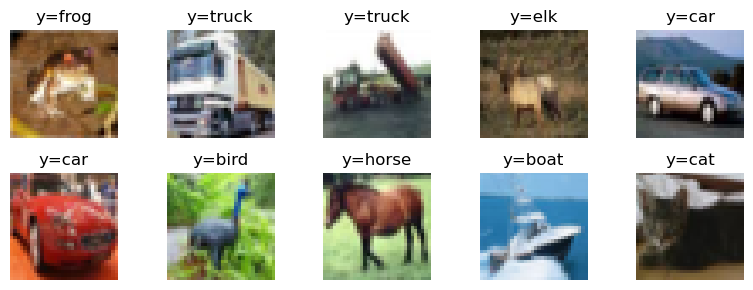

In [20]:
# read in our data and visualize some examples

# Load the MNIST dataset and split into training and testing sets
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

labels = ['frog', 'truck', 'truck', 'elk', 'car', 'car', 'bird', 'horse', 'boat', 'cat']

# Visualize a few examples
fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"y={labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Note that for the sake of brevity we will skip doing our typical training/validation steps. 

### Baseline Model: Logistic Regression

To show why we need NNs, let's show what happens when we perform a **logistic regression**. This is similar to our previous regression examples, except we use a function transformation to turn our outputs into probabilities of belonging in a category. We will cover some basics of classification later, so for now don't worry about the specifics. 

In [24]:
# Training Logistic Regression 

X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1) # flatten images so 2D for logistic regression

X_train = X_train / 255.0
X_test  = X_test / 255.0 # normalize outputs 

logreg = LogisticRegression(random_state=1515)

logreg.fit(X_train, y_train)

logreg_pred_train = logreg.predict(X_train)
logreg_pred_test = logreg.predict(X_test)

logreg_train_acc = accuracy_score(y_train, logreg_pred_train)
logreg_test_acc  = accuracy_score(y_test, logreg_pred_test)

print(f"Logistic Regression Training Accuracy: {logreg_train_acc:3f}")
print(f"Logistic Regression Test Accuracy: {logreg_test_acc:3f}")

Logistic Regression Training Accuracy: 0.429220
Logistic Regression Test Accuracy: 0.406300


As we can see, our performance is pretty poor! Let's try to use a NN to see what will happen.

### Improvement Attempt #1: Basic NN

NNs are also known as Multi-Layer Perceptrons (MLPs). For our first attempt, let's try MLP with one hidden layer: 

In [35]:
# Training NN 1 

mlp1 = MLPClassifier(random_state=1515)


mlp1.fit(X_train, y_train)

mlp1_pred_train = mlp1.predict(X_train)
mlp1_pred_test = mlp1.predict(X_test)

mlp1_train_acc = accuracy_score(y_train, mlp1_pred_train)
mlp1_test_acc  = accuracy_score(y_test, mlp1_pred_test)

print(f"MLP 1 Regression Training Accuracy: {mlp1_train_acc:3f}")
print(f"MLP 1 Regression Test Accuracy: {mlp1_test_acc:3f}")

MLP 1 Regression Training Accuracy: 0.550260
MLP 1 Regression Test Accuracy: 0.464700


We see some slight improvement, but definitely nothing extreme. This is an unsurprising result - we only added one nonlinear transformation! To illustrate, let's try adding some more. 

### Improvement Attempt #2: More Hidden Layers

Now, we add more hidden layers. There are some other arguments in there - do not worry about those meanings! If interested in more advanced ML, learning these topics is helpful, but we just want to gain an understanding of these models.

In [44]:
# Training NN 2 

mlp2 = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42
)

mlp2.fit(X_train, y_train)

mlp2_pred_train = mlp2.predict(X_train)
mlp2_pred_test = mlp2.predict(X_test)

mlp2_train_acc = accuracy_score(y_train, mlp2_pred_train)
mlp2_test_acc  = accuracy_score(y_test, mlp2_pred_test)

print(f"MLP 2 Regression Training Accuracy: {mlp2_train_acc:3f}")
print(f"MLP 2 Regression Test Accuracy: {mlp2_test_acc:3f}")

MLP 2 Regression Training Accuracy: 0.672580
MLP 2 Regression Test Accuracy: 0.518100


We see some decent improvement, although we see more overfitting, which is not surprising because we are adding more complexity to our model without doing any form of regularization.

### Why Our Accuracy is Still Low: Flaw of basic NNs

Admittedly, for all of this talk about NNs, our accuracy was not *that* much better than the Logistic Regression baseline. Why? 

Well, if we think about how NNs work, we flattened our images for inputs, which reduces the amount of information our model has. The un-flattened image removes spatial structure information, which is very useful in developing **positional invariance**, or the ability to classify images regardless of where in the image the object lies. 

The reason this occurs is because pixels in a given "neighborhood" or area of the picture are related (similar), so features like edges depend on this information, which we remove by flattening our image. 

But, once we have this information by un-flattening the image, how do we capture it? 

We use **convolution**!